# <font color="#7AAACE">Clasificación Multiclase de Riesgo Crediticio mediante Redes Neuronales Artificiales</font>



El análisis del riesgo crediticio es uno de los problemas más importantes dentro del sector financiero, ya que permite estimar la probabilidad de que un cliente cumpla o no con sus obligaciones de pago. Las instituciones financieras utilizan esta información para tomar decisiones relacionadas con la aprobación de préstamos, límites de crédito y condiciones de financiamiento.

En este proyecto se desarrolla un modelo de **Red Neuronal Artificial (Artificial Neural Network - ANN)** con el objetivo de **clasificar a los clientes según su nivel de riesgo crediticio**, utilizando información relacionada con su perfil financiero y comportamiento crediticio. El problema se plantea como una **tarea de clasificación multiclase**, donde el modelo debe asignar a cada cliente una categoría de **Credit Score (0, 1 o 2)** que representa diferentes niveles de riesgo.

El conjunto de datos utilizado contiene múltiples variables que describen el comportamiento financiero del cliente, incluyendo ingresos, número de cuentas bancarias, utilización de crédito, deuda pendiente, historial crediticio y comportamiento de pago. Estas variables permiten construir un perfil crediticio integral que puede ser utilizado por algoritmos de aprendizaje automático para identificar patrones asociados con distintos niveles de riesgo.

El desarrollo del proyecto sigue un pipeline completo de ciencia de datos, que incluye **exploración de datos, limpieza, preprocesamiento, reducción de dimensionalidad y entrenamiento de un modelo de red neuronal** capaz de aprender relaciones complejas entre las variables del dataset.

## <font color="#7AAACE">Carga y exploración de datos</font>

La primera etapa del proyecto consiste en la carga del conjunto de datos y en la exploración inicial de su estructura. Esta fase es fundamental para comprender la naturaleza de la información disponible, identificar el tipo de variables presentes y detectar posibles problemas de calidad en los datos.

Durante esta etapa se realiza la lectura del dataset desde una fuente externa en formato Excel y se almacena en una estructura tipo **DataFrame**, lo que permite manipular los datos de manera eficiente. Posteriormente se inspeccionan las primeras observaciones del conjunto de datos, se revisan los tipos de variables y se analizan estadísticas descriptivas básicas.

Este análisis exploratorio permite identificar variables numéricas y categóricas, observar la distribución de los datos y detectar posibles valores atípicos o inconsistencias. También se examina la distribución de la variable objetivo **Credit_Score**, con el fin de evaluar si existe un desbalance entre las clases que pueda afectar el entrenamiento del modelo.

La exploración de datos constituye una etapa clave dentro del flujo de trabajo, ya que proporciona una comprensión inicial del dataset y orienta las decisiones que se tomarán posteriormente en las fases de limpieza y transformación de los datos.


### <font color="#7AAACE">1. Importación de librerías</font>

En este bloque se importan las librerías fundamentales para el desarrollo del análisis y la construcción del modelo. `pandas` se utiliza para la manipulación estructurada de los datos en forma tabular, `numpy` para operaciones numéricas vectorizadas, `matplotlib.pyplot` para la generación de visualizaciones base y `seaborn` para gráficos estadísticos con una presentación más clara. Esta etapa es esencial porque define el entorno de trabajo y reúne las herramientas necesarias para las fases posteriores de exploración, limpieza, preprocesamiento, modelado y evaluación.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### <font color="#7AAACE">2. Verificación de versiones del entorno</font>

En este bloque se verifica la versión de Python y de las librerías principales utilizadas en el cuaderno. Esta validación permite documentar el entorno de ejecución, lo cual es importante desde el punto de vista de la reproducibilidad experimental. En problemas de aprendizaje automático, diferencias en versiones pueden afectar compatibilidad, resultados numéricos o disponibilidad de funciones, por lo que registrar esta información fortalece la trazabilidad técnica del procedimiento.


In [2]:
# Ver la version de Python
!python --version

# Ver la version de las librerias
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"seaborn version: {sns.__version__}")

Python 3.12.12
pandas version: 2.2.2
numpy version: 2.0.2
seaborn version: 0.13.2


### <font color="#7AAACE">3. Carga del archivo desde GitHub</font>

Aquí se realiza la carga del conjunto de datos desde una fuente remota en formato Excel. Se utiliza `pd.read_excel()` para leer directamente el archivo y almacenarlo en un `DataFrame`, que será la estructura de trabajo principal durante todo el proceso. Posteriormente, se imprime el número de filas y columnas para validar que la lectura haya sido exitosa y para tener una primera referencia del tamaño del problema. Esta comprobación inicial permite detectar fallos de acceso, corrupción del archivo o inconsistencias estructurales desde el inicio.


In [3]:
url = "https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx"
df = pd.read_excel(url)
print("Archivo cargado correctamente")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Archivo cargado correctamente
Filas: 12500 | Columnas: 26


### <font color="#7AAACE">4. Visualización de las primeras filas</font>

En este bloque se inspeccionan las primeras observaciones del conjunto de datos mediante `df.head()`. Esta revisión exploratoria temprana permite identificar la estructura general de las variables, el tipo de información contenida en cada columna y posibles anomalías visibles, como formatos incorrectos, categorías mal escritas o valores atípicos evidentes. Es una práctica estándar de análisis exploratorio porque ayuda a comprender el dominio de los datos antes de aplicar transformaciones.


In [4]:
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


### <font color="#7AAACE">5. Inspección de tipos de datos</font>

En este paso se consultan los tipos de datos de cada variable usando `df.dtypes`. Esta verificación es clave porque el tipo de dato determina el tratamiento posterior de cada columna. Las variables numéricas pueden escalarse, resumirse estadísticamente o emplearse directamente en el modelo, mientras que las variables categóricas requieren transformación previa. Identificar correctamente esta distinción es indispensable para diseñar un pipeline de preprocesamiento coherente.


In [5]:
df.dtypes

,0
Customer_ID,object
Name,object
Age,float64
SSN,object
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,float64
Num_Credit_Card,float64
Interest_Rate,int64


### <font color="#7AAACE">6. Estadísticas descriptivas básicas</font>

Este bloque calcula estadísticas descriptivas para las variables numéricas mediante `df.describe()`. El objetivo es obtener una caracterización cuantitativa inicial del conjunto de datos, incluyendo tendencia central, dispersión y rango. Estos indicadores permiten detectar posibles escalas muy diferentes entre variables, presencia de valores extremos y distribución general de los atributos. Esta información es especialmente útil para justificar la necesidad posterior de normalización.

In [6]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.00000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,33.311294,50505.123449,4198.468568,5.368828,5.53362,14.532080,3.532880,21.068780,13.338642,10.465068,5.779694,1426.220376,32.285069,18.433820,107.698610,195.751837,403.120320,0.845200
std,10.760177,38300.762656,3187.142979,2.592493,2.06604,8.741636,2.446442,14.772965,6.153148,6.445141,3.707936,1155.169458,2.060154,8.304817,118.990964,136.847120,175.476887,0.697994
min,14.000000,7005.930000,303.645417,0.000000,0.50000,1.000000,0.000000,-2.000000,0.000000,0.500000,0.000000,0.230000,25.476634,0.375000,0.000000,14.528879,92.841401,0.000000
25%,24.415179,19342.972500,1625.744479,3.000000,4.00000,7.000000,2.000000,9.875000,9.000000,5.493750,3.000000,566.072500,30.854492,12.041667,30.333649,97.690749,284.546710,0.000000
50%,33.000000,36999.705000,3097.016667,5.375000,5.00000,13.000000,3.000000,17.875000,13.750000,9.370000,5.250000,1166.155000,32.241830,18.238095,68.102176,152.081485,338.491580,1.000000
75%,41.750000,71683.470000,5961.664375,7.000000,7.00000,20.000000,5.000000,28.000000,18.175000,14.656250,8.500000,1945.962500,33.600168,25.125000,151.220882,257.566585,465.372970,1.000000
max,56.000000,179987.280000,15204.633333,10.500000,10.87500,34.000000,9.000000,63.250000,26.375000,31.115000,16.375000,4998.070000,42.395301,33.380952,1515.158986,1005.847285,1349.264887,2.000000


### <font color="#7AAACE">7. Detección de valores nulos</font>

Aquí se cuantifica la cantidad de valores faltantes por columna mediante `df.isnull().sum()`. Esta etapa forma parte del diagnóstico de calidad de datos y permite identificar variables con información incompleta que podrían afectar la estabilidad del modelo. El análisis de valores nulos es necesario porque una red neuronal no puede operar directamente sobre entradas con datos ausentes, por lo que antes del entrenamiento debe definirse una estrategia de tratamiento adecuada.


In [7]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0


### <font color="#7AAACE">8. Distribución de la variable objetivo</font>

En este bloque se analiza la distribución de la variable objetivo `Credit_Score` tanto de forma tabular como gráfica. El conteo de clases permite determinar si existe desbalance entre categorías, mientras que el gráfico de barras facilita una interpretación visual de esa distribución. Esta evaluación es importante porque la composición de la variable objetivo influye directamente en la estrategia de partición del conjunto de datos y en la interpretación posterior de métricas como accuracy, precisión y recall.


Credit_Score
1    6111
0    4162
2    2227
Name: count, dtype: int64


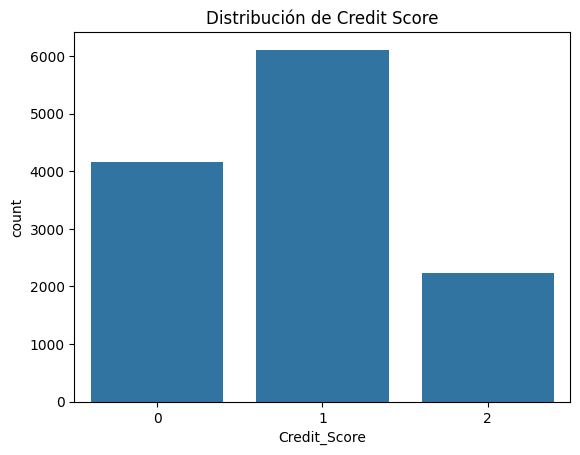

In [8]:
print(df['Credit_Score'].value_counts())

sns.countplot(x='Credit_Score', data=df)
plt.title('Distribución de Credit Score')
plt.show()

## <font color="#7AAACE">Limpieza de datos</font>

La limpieza de datos es una etapa fundamental para garantizar la calidad de la información que será utilizada en el entrenamiento del modelo. En esta fase se identifican y corrigen problemas como valores faltantes, columnas irrelevantes o inconsistencias en las variables categóricas.

En primer lugar, se eliminan variables que no aportan información relevante para el modelo, como identificadores únicos o datos personales del cliente, por ejemplo **Customer_ID, Name y SSN**, ya que estas columnas no contienen información útil para la predicción del riesgo crediticio y podrían introducir ruido en el proceso de aprendizaje.

Posteriormente se analizan los valores nulos presentes en el dataset y se aplican estrategias de imputación cuando es necesario. En algunos casos, los valores faltantes en variables categóricas se reemplazan por categorías representativas que indican ausencia de información.

También se revisan las variables categóricas para identificar valores inconsistentes o poco informativos. Algunas categorías se agrupan o transforman para mejorar la calidad semántica de los datos y facilitar su posterior conversión a formato numérico.

Esta fase permite obtener un conjunto de datos más consistente y confiable, lo cual es esencial para que el modelo de aprendizaje automático pueda identificar patrones reales sin verse afectado por errores o inconsistencias en la información.


### <font color="#7AAACE">9. Identificación precisa de columnas con nulos</font>

En este paso se filtran únicamente las columnas que presentan valores nulos. Esta operación no solo confirma la existencia de datos faltantes, sino que permite focalizar la limpieza en variables específicas. Desde una perspectiva metodológica, este filtrado evita aplicar transformaciones innecesarias sobre columnas completas y facilita justificar cada decisión de imputación o transformación en función del problema real detectado.


In [9]:
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Type_of_Loan    1426
dtype: int64


### <font color="#7AAACE">10. Eliminación de columnas irrelevantes</font>

En este bloque se eliminan las columnas `Customer_ID`, `Name` y `SSN`, debido a que corresponden a identificadores o información nominal que no aporta valor predictivo real al problema de clasificación. Además, este tipo de variables puede introducir ruido, alta cardinalidad y patrones espurios que no representan relaciones causales ni estructurales con la variable objetivo. Su eliminación mejora la calidad del espacio de características y evita que el modelo aprenda asociaciones irrelevantes.

In [10]:
columnas_eliminar = ['Customer_ID', 'Name', 'SSN']
df = df.drop(columns=columnas_eliminar)
print(f"Columnas eliminadas. Ahora el dataset tiene {df.shape[1]} columnas")

Columnas eliminadas. Ahora el dataset tiene 23 columnas


### <font color="#7AAACE">11. Identificación de columnas categóricas restantes</font>

Aquí se identifican las columnas de tipo categórico que permanecen en el conjunto de datos tras la eliminación de variables irrelevantes. Esta revisión permite delimitar qué atributos todavía requieren codificación antes de ser utilizados en algoritmos de aprendizaje supervisado. Dado que las redes neuronales trabajan sobre representaciones numéricas, esta etapa es necesaria para planificar la transformación de las variables de texto a un formato compatible.

In [11]:
categoricas = df.select_dtypes(include='object').columns.tolist()
print("Columnas de tipo texto (categóricas):")
print(categoricas)

Columnas de tipo texto (categóricas):
['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


### <font color="#7AAACE">12. Análisis de la variable Type_of_Loan</font>

En este bloque se exploran los valores de la variable `Type_of_Loan`, con el propósito de comprender su estructura semántica y su nivel de variabilidad. Esta inspección es importante porque no se trata de una categoría simple, sino de una columna que puede contener múltiples tipos de préstamo en una misma observación. Analizarla previamente permite diseñar una estrategia de transformación más informativa que una simple codificación categórica directa.


In [12]:
print(df['Type_of_Loan'].value_counts())

Type_of_Loan
Not Specified                                                                                 176
Credit-Builder Loan                                                                           160
Personal Loan                                                                                 159
Debt Consolidation Loan                                                                       158
Student Loan                                                                                  155
                                                                                             ... 
Mortgage Loan, Home Equity Loan, Personal Loan, and Personal Loan                               1
Debt Consolidation Loan, Mortgage Loan, Payday Loan, and Debt Consolidation Loan                1
Home Equity Loan, Debt Consolidation Loan, Personal Loan, Not Specified, and Mortgage Loan      1
Auto Loan, Personal Loan, Auto Loan, and Auto Loan                                              1
Payday 

### <font color="#7AAACE">13. Imputación de nulos en Type_of_Loan</font>

En este paso se reemplazan los valores nulos de la columna `Type_of_Loan` por la categoría `Not Specified`. Esta decisión evita perder registros completos y permite conservar la información de ausencia como una condición explícita dentro del conjunto de datos. Técnicamente, esta imputación es adecuada porque la variable es categórica y el valor agregado representa de forma interpretable la falta de especificación del tipo de préstamo.


In [13]:
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')
print(f"Nulos en Type_of_Loan: {df['Type_of_Loan'].isnull().sum()}")

Nulos en Type_of_Loan: 0


### <font color="#7AAACE">14. Transformación de Type_of_Loan en conteo de préstamos</font>

En este bloque se realiza una ingeniería de características sobre la variable `Type_of_Loan`. En lugar de conservar el texto original, se define una función que cuenta cuántos tipos de préstamo están asociados a cada registro. Con ello, se transforma una columna categórica compleja y de alta variabilidad en una característica numérica más compacta e interpretable: el número de tipos de préstamo. Esta transformación reduce dimensionalidad semántica, preserva información relevante sobre complejidad financiera del cliente y mejora la compatibilidad con el modelo.


In [14]:
def contar_prestamos(texto):
    if pd.isnull(texto) or texto == 'Not Specified':
        return 0
    return len(texto.split(','))

df['Num_of_Loan_Types'] = df['Type_of_Loan'].apply(contar_prestamos)
df = df.drop(columns=['Type_of_Loan'])

print("Type_of_Loan convertida a Num_of_Loan_Types")
print(df['Num_of_Loan_Types'].value_counts().sort_index())

Type_of_Loan convertida a Num_of_Loan_Types
Num_of_Loan_Types
0    1602
1    1215
2    1964
3    1969
4    1932
5     941
6    1018
7     960
8     417
9     482
Name: count, dtype: int64


### <font color="#7AAACE">15. Revisión de valores únicos en variables categóricas</font>

Aquí se analizan los valores únicos y sus frecuencias en las variables categóricas restantes. El objetivo es comprender la cardinalidad de cada atributo, detectar categorías irregulares y verificar la consistencia de los datos antes de su codificación. Esta inspección también permite identificar categorías ambiguas o problemáticas, como valores no informativos, errores de captura o etiquetas poco representativas, lo cual resulta clave para una transformación adecuada.

---

In [15]:
categoricas = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categoricas:
    print(f"\n {col} ({df[col].nunique()} valores únicos):")
    print(df[col].value_counts())


 Occupation (15 valores únicos):
Occupation
Lawyer           887
Engineer         858
Architect        853
Mechanic         847
Scientist        843
Accountant       843
Media_Manager    840
Developer        840
Teacher          834
Entrepreneur     831
Doctor           821
Journalist       817
Manager          804
Musician         794
Writer           788
Name: count, dtype: int64

 Credit_Mix (3 valores únicos):
Credit_Mix
Standard    5731
Good        3798
Bad         2971
Name: count, dtype: int64

 Payment_of_Min_Amount (3 valores únicos):
Payment_of_Min_Amount
Yes    7360
No     5031
NM      109
Name: count, dtype: int64

 Payment_Behaviour (6 valores únicos):
Payment_Behaviour
Low_spent_Small_value_payments      3860
High_spent_Medium_value_payments    3086
High_spent_Large_value_payments     2726
Low_spent_Medium_value_payments     1136
High_spent_Small_value_payments      972
Low_spent_Large_value_payments       720
Name: count, dtype: int64


### <font color="#7AAACE">16. Reemplazo de NM en Payment_of_Min_Amount</font>

En este bloque se reemplaza el valor `NM` por `Yes` dentro de la columna `Payment_of_Min_Amount`. Esta decisión se basa en un criterio de imputación por moda, es decir, se sustituye una categoría anómala o ambigua por la categoría más frecuente. El objetivo es reducir ruido semántico en la variable y evitar que el modelo interprete `NM` como una categoría independiente cuando en realidad no aporta información clara o consistente.

In [16]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'Yes')
print("Valores en Payment_of_Min_Amount:")
print(df['Payment_of_Min_Amount'].value_counts())

Valores en Payment_of_Min_Amount:
Payment_of_Min_Amount
Yes    7469
No     5031
Name: count, dtype: int64


### <font color="#7AAACE">17. Importación de LabelEncoder</font>

En este paso se importa la clase `LabelEncoder` de `sklearn.preprocessing`, la cual se utilizará para convertir variables categóricas a representaciones numéricas enteras. Esta herramienta resulta apropiada cuando se desea mapear cada categoría textual a un valor numérico único, permitiendo que el algoritmo procese dichas variables. Su uso es una fase previa indispensable para integrar atributos categóricos dentro del pipeline de modelado.



In [17]:
from sklearn.preprocessing import LabelEncoder

### <font color="#7AAACE">18. Codificación de variables categóricas</font>

Aquí se codifican las variables categóricas seleccionadas mediante `LabelEncoder`. Para cada columna, el procedimiento ajusta un mapeo entre etiquetas textuales y enteros, y posteriormente reemplaza los valores originales por su representación numérica. Esta transformación permite que las variables puedan ser utilizadas por la red neuronal, que requiere entradas numéricas. Además, al finalizar se imprime una muestra del dataset actualizado para verificar que la conversión se haya realizado correctamente.


In [18]:
le = LabelEncoder()
columnas_label = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in columnas_label:
    df[col] = le.fit_transform(df[col])
    print(f"{col} codificada")

print("\nPrimeras filas del dataset actualizado:")
print(df.head())

Occupation codificada
Credit_Mix codificada
Payment_of_Min_Amount codificada
Payment_Behaviour codificada

Primeras filas del dataset actualizado:
      Age  Occupation  Annual_Income  Monthly_Inhand_Salary  \
0  17.375           7       30625.94            2706.161667   
1  25.750           9       52312.68            4250.390000   
2  18.500          10      113781.39            9549.782500   
3  43.875           3       58918.47            5208.872500   
4  43.750           9       98620.98            7962.415000   

   Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
0                6.0              5.0             27            2   
1                6.0              5.0             17            4   
2                1.0              4.0              1            0   
3                3.0              3.0             17            3   
4                3.0              3.0              6            3   

   Delay_from_due_date  Num_of_Delayed_Payment  ...  Outsta

### <font color="#7AAACE">19. Verificación de ausencia de columnas de texto</font>

En este bloque se valida que ya no queden columnas de tipo texto dentro del conjunto de datos. Esta comprobación garantiza que todo el `DataFrame` tenga una representación completamente numérica, condición necesaria para proceder con operaciones como escalado, reducción de dimensionalidad y entrenamiento del modelo. También se imprime la forma del dataset y los tipos de datos finales para documentar el estado del conjunto tras la limpieza y transformación.


In [19]:
categoricas_restantes = df.select_dtypes(include='object').columns.tolist()
print(f"Columnas de texto restantes: {categoricas_restantes}")
print(f"Forma del dataset: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")

Columnas de texto restantes: []
Forma del dataset: (12500, 23)

Tipos de datos:
Age                         float64
Occupation                    int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                    int64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount         int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour             int64
Monthly_Balance             float64
Credit_Score                  int64
Num_of_Loan_Types             int64
dtype: object


## <font color="#7AAACE">Preprocesamiento</font>

Una vez que los datos han sido limpiados, se procede a realizar el preprocesamiento necesario para preparar el dataset para el entrenamiento del modelo. Esta etapa incluye varias transformaciones que permiten adaptar los datos a los requerimientos de los algoritmos de aprendizaje automático.

En primer lugar, las variables categóricas se transforman en representaciones numéricas utilizando técnicas de codificación como **Label Encoding**, lo cual permite que las redes neuronales puedan procesar este tipo de variables.

Posteriormente se realiza la **normalización de las variables numéricas** mediante técnicas de escalado, específicamente utilizando **StandardScaler**. Este procedimiento ajusta la distribución de las variables para que tengan una media cercana a cero y una desviación estándar cercana a uno. La normalización es especialmente importante en redes neuronales, ya que mejora la estabilidad numérica del entrenamiento y acelera la convergencia del modelo.

Adicionalmente, se aplica una técnica de **reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA)**. El objetivo de este proceso es reducir el número de variables del dataset manteniendo la mayor cantidad posible de información relevante. Esto permite disminuir la complejidad del modelo, eliminar redundancia entre variables y mejorar la eficiencia computacional durante el entrenamiento.

Finalmente, el conjunto de datos se divide en tres subconjuntos: **entrenamiento, validación y prueba**, asegurando que cada uno mantenga una distribución similar de las clases del Credit Score.

### <font color="#7AAACE">20. Separación entre variables predictoras y variable objetivo</font>
En este paso se separan las características predictoras (`X`) de la variable objetivo (`y`). Esta división es fundamental en aprendizaje supervisado, ya que permite estructurar explícitamente el problema en términos de entradas y salida esperada. También se reportan dimensiones y distribución de la variable objetivo, lo cual ayuda a verificar que la separación se realizó correctamente y que la variable de salida mantiene una distribución coherente antes de la partición del dataset.

---

In [20]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

print(f"X (features): {X.shape}")
print(f"y (target): {y.shape}")
print(f"\nColumnas de X:\n{X.columns.tolist()}")
print(f"\nDistribución de y:\n{y.value_counts()}")

X (features): (12500, 22)
y (target): (12500,)

Columnas de X:
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Num_of_Loan_Types']

Distribución de y:
Credit_Score
1    6111
0    4162
2    2227
Name: count, dtype: int64


### <font color="#7AAACE">21. División en entrenamiento, validación y prueba</font>

En este bloque se divide el conjunto de datos en tres subconjuntos: entrenamiento, validación y prueba. Primero se separa un 70% para entrenamiento y un 30% temporal; luego este 30% se divide equitativamente en validación y prueba. Se utiliza `stratify` para preservar la proporción de clases en cada subconjunto, lo cual es especialmente importante en problemas de clasificación multiclase. Esta estrategia permite entrenar el modelo, ajustar hiperparámetros con datos no vistos durante el entrenamiento y finalmente evaluar su capacidad de generalización sobre un conjunto completamente independiente.


In [21]:
from sklearn.model_selection import train_test_split

# Primero separamos el 70% train y 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Luego dividimos el 30% temporal en 15% validation y 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (8750, 22)
X_val:   (1875, 22)
X_test:  (1875, 22)


### <font color="#7AAACE">22. Normalización con StandardScaler</font>

En este bloque se normalizan las variables de entrada utilizando `StandardScaler`, que transforma cada característica para que tenga media cercana a cero y desviación estándar cercana a uno. El escalador se ajusta únicamente con los datos de entrenamiento y luego se aplica a validación y prueba, evitando así fuga de información. Este procedimiento es crucial en redes neuronales porque facilita la estabilidad numérica, mejora la convergencia del optimizador y evita que variables con escalas mayores dominen el proceso de aprendizaje.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Normalización completada")
print(f"Media aproximada de X_train_scaled:  {X_train_scaled.mean():.4f}")
print(f"Desviación estándar de X_train_scaled: {X_train_scaled.std():.4f}")

Normalización completada
Media aproximada de X_train_scaled:  -0.0000
Desviación estándar de X_train_scaled: 1.0000


### <font color="#7AAACE">23. Análisis de varianza explicada con PCA</font>

Aquí se aplica un análisis de componentes principales (PCA) inicial sobre los datos normalizados de entrenamiento con el fin de estudiar cuánta varianza acumulada puede explicarse a medida que aumenta el número de componentes. La gráfica generada permite identificar el punto a partir del cual se conserva un porcentaje alto de la información original, en este caso tomando como referencia el 95%. Este análisis es importante porque justifica técnicamente la elección posterior del número de componentes y permite reducir la dimensionalidad sin una pérdida excesiva de información.


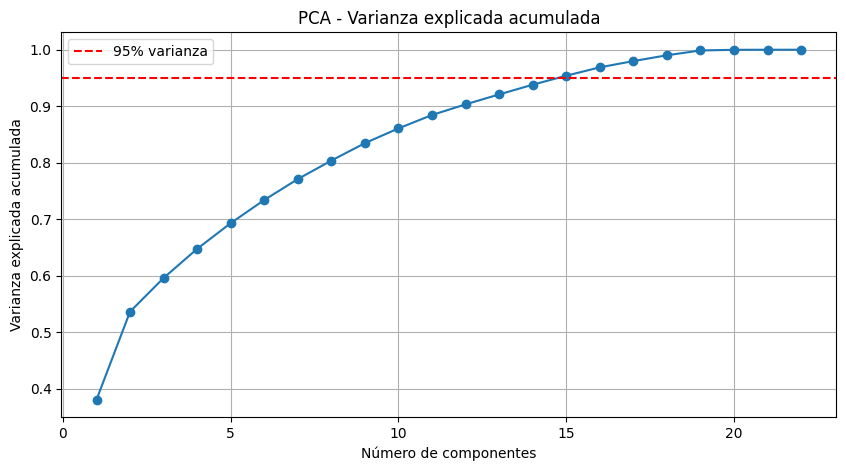

Componentes necesarios para explicar el 95% de la varianza: 15


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Primero graficamos la varianza explicada para decidir cuántos componentes usar
pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza_acumulada = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.legend()
plt.grid(True)
plt.show()

# Cuántos componentes necesitamos para el 95% de varianza
n_componentes = (varianza_acumulada >= 0.95).argmax() + 1
print(f"Componentes necesarios para explicar el 95% de la varianza: {n_componentes}")

### <font color="#7AAACE">24. Aplicación de PCA con 15 componentes</font>

En este bloque se aplica PCA fijando explícitamente 15 componentes principales. La reducción de dimensionalidad busca condensar la información relevante del conjunto original en un espacio más compacto, eliminando redundancia lineal entre variables y disminuyendo el ruido. El ajuste se realiza únicamente sobre el conjunto de entrenamiento y después se transforma validación y prueba usando la misma proyección, preservando la consistencia metodológica y evitando fuga de información. Además, esta reducción puede mejorar eficiencia computacional y capacidad de generalización del modelo.



In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=15)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA aplicado")
print(f"X_train_pca: {X_train_pca.shape}")
print(f"X_val_pca:   {X_val_pca.shape}")
print(f"X_test_pca:  {X_test_pca.shape}")

PCA aplicado
X_train_pca: (8750, 15)
X_val_pca:   (1875, 15)
X_test_pca:  (1875, 15)


### <font color="#7AAACE">25. Almacenamiento de objetos de preprocesamiento</font>

En este paso se guardan en disco los objetos `scaler` y `pca` utilizando `joblib`. Esto permite reutilizar exactamente las mismas transformaciones en etapas futuras, como validación externa, inferencia sobre nuevos datos o despliegue del modelo. Guardar los objetos de preprocesamiento es una buena práctica porque asegura consistencia entre entrenamiento y uso operativo del sistema, evitando discrepancias entre el tratamiento de datos en distintas fases.


In [25]:
import joblib

joblib.dump(scaler, 'scaler_ann.pkl')
joblib.dump(pca, 'pca_ann.pkl')

print("scaler_ann.pkl guardado")
print("pca_ann.pkl guardado")

scaler_ann.pkl guardado
pca_ann.pkl guardado


### <font color="#7AAACE">26. Resumen final del preprocesamiento</font>

En este bloque se presenta un resumen consolidado del pipeline de preprocesamiento, incluyendo tamaño original del dataset, forma final tras la limpieza y dimensiones resultantes de los subconjuntos transformados con PCA. Esta síntesis permite documentar de manera clara el efecto de las transformaciones aplicadas y deja evidencia del flujo completo antes de iniciar la etapa de modelado. Es útil tanto para interpretación técnica como para auditoría metodológica.


In [26]:
print("=" * 45)
print("     RESUMEN DEL PREPROCESAMIENTO")
print("=" * 45)
print(f"Dataset original:      (12500, 26)")
print(f"Después de limpieza:   {df.shape}")
print(f"Train:  {X_train_pca.shape}")
print(f"Val:    {X_val_pca.shape}")
print(f"Test:   {X_test_pca.shape}")
print(f"Clases: {sorted(y.unique().tolist())}")
print("=" * 45)

     RESUMEN DEL PREPROCESAMIENTO
Dataset original:      (12500, 26)
Después de limpieza:   (12500, 23)
Train:  (8750, 15)
Val:    (1875, 15)
Test:   (1875, 15)
Clases: [0, 1, 2]


## <font color="#7AAACE">Entrenamiento</font>

La etapa final del proyecto corresponde al entrenamiento de una **Red Neuronal Artificial (ANN)** diseñada para resolver el problema de clasificación multiclase del riesgo crediticio.

El modelo se construye utilizando varias capas densas completamente conectadas que permiten capturar relaciones no lineales entre las variables de entrada. Las capas ocultas utilizan funciones de activación **ReLU**, las cuales facilitan el aprendizaje de representaciones complejas a partir de los datos.

Para mejorar la estabilidad del entrenamiento se incorporan técnicas como **Batch Normalization**, que ayuda a mantener distribuciones estables en las activaciones de la red, y **Dropout**, que reduce el riesgo de sobreajuste al desactivar aleatoriamente algunas neuronas durante el proceso de aprendizaje.

La capa de salida utiliza una función de activación **Softmax**, que permite obtener probabilidades para cada una de las tres clases de la variable objetivo: **Credit Score 0, 1 y 2**.

El modelo se entrena utilizando el optimizador **Adam** y la función de pérdida **sparse categorical crossentropy**, apropiada para problemas de clasificación multiclase con etiquetas codificadas como enteros.

Durante el entrenamiento se emplean mecanismos como **Early Stopping**, que detiene el proceso cuando el modelo deja de mejorar en el conjunto de validación, y **Model Checkpoint**, que permite guardar automáticamente la mejor versión del modelo. Finalmente, el desempeño del modelo se evalúa utilizando métricas como **accuracy, precision, recall y matriz de confusión**, con el objetivo de analizar su capacidad de generalización sobre datos no vistos.

### <font color="#7AAACE">27. Instalación de dependencias para la ANN</font>

En este bloque se instalan las librerías necesarias para la construcción y entrenamiento de la red neuronal artificial, incluyendo `tensorflow`, `keras`, `scikit-learn`, `openpyxl` y `joblib`. Aunque varias de estas librerías ya pudieron haber sido utilizadas anteriormente, esta instalación garantiza que el entorno cuente con todos los paquetes requeridos para ejecutar la fase de modelado. Desde el punto de vista técnico, esto contribuye a la portabilidad del notebook entre distintos entornos de ejecución.


In [27]:
!pip install scikit-learn tensorflow keras openpyxl joblib -q
print("Librerías instaladas")

Librerías instaladas


### <font color="#7AAACE">28. Construcción de la arquitectura de la red neuronal</font>

Aquí se define la arquitectura de la red neuronal artificial utilizando la API secuencial de Keras. Primero se fija una semilla aleatoria para favorecer la reproducibilidad del experimento. La red recibe como entrada un vector de 15 características, correspondiente al espacio transformado por PCA. Posteriormente, se construyen tres capas densas ocultas con activación ReLU, lo que permite modelar relaciones no lineales entre las variables. Se incorporan capas de `BatchNormalization` para estabilizar la distribución interna de activaciones y acelerar el entrenamiento, así como capas `Dropout` para reducir el riesgo de sobreajuste mediante desactivación aleatoria de neuronas durante el aprendizaje. Finalmente, la capa de salida utiliza `softmax` con tres neuronas, ya que el problema corresponde a una clasificación multiclase de tres categorías de puntaje crediticio.



In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijar semilla para reproducibilidad
tf.random.set_seed(42)

modelo = keras.Sequential([
    # Capa de entrada
    layers.Input(shape=(15,)),

    # Capa oculta 1
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 2
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 3
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Capa de salida (3 clases)
    layers.Dense(3, activation='softmax')
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 12,867 (50.26 KB)

 Non-trainable params: 384 (1.50 KB)

### <font color="#7AAACE">29. Compilación del modelo</font>

En este bloque se compila la red neuronal definiendo el optimizador, la función de pérdida y la métrica principal de evaluación. Se utiliza `adam` por su eficiencia y capacidad adaptativa en problemas de optimización estocástica, `sparse_categorical_crossentropy` como función de pérdida porque la variable objetivo está codificada como enteros de clase y no en formato one-hot, y `accuracy` como métrica global de desempeño. Esta configuración es coherente con la naturaleza del problema de clasificación multiclase supervisada.

In [29]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado")

Modelo compilado


### <font color="#7AAACE">30. Entrenamiento del modelo con EarlyStopping y ModelCheckpoint</font>

En este paso se entrena la red neuronal utilizando los datos de entrenamiento y validación. Se implementa `EarlyStopping` monitoreando la pérdida de validación para detener el entrenamiento cuando el modelo deja de mejorar, lo que ayuda a prevenir sobreajuste y reduce entrenamiento innecesario. Además, se emplea `ModelCheckpoint` para guardar automáticamente la mejor versión del modelo según la accuracy de validación. El entrenamiento se realiza con un máximo de 100 épocas y lotes de tamaño 32, lo cual permite un balance adecuado entre estabilidad de gradiente y eficiencia computacional. Esta configuración convierte el entrenamiento en un proceso controlado, reproducible y orientado a generalización.



In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping para que pare si no mejora
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Guardar el mejor modelo automáticamente
checkpoint = ModelCheckpoint(
    'modelo_ann.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

historia = modelo.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

print("✅ Entrenamiento completado")


Epoch 1/100
272/274 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5472 - loss: 1.0327
Epoch 1: val_accuracy improved from -inf to 0.68320, saving model to modelo_ann.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5478 - loss: 1.0312 - val_accuracy: 0.6832 - val_loss: 0.6960
Epoch 2/100
269/274 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6726 - loss: 0.7323
Epoch 2: val_accuracy improved from 0.68320 to 0.71200, saving model to modelo_ann.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6728 - loss: 0.7323 - val_accuracy: 0.7120 - val_loss: 0.6544
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7083 - loss: 0.6835
Epoch 3: val_accuracy improved from 0.71200 to 0.71733, saving model to modelo_ann.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7083 - loss: 0.6836 - val_accuracy: 0.7173 - val_loss: 0.6413
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7181 - loss: 0.6532
Epoch 4: val_accuracy improved from 

### <font color="#7AAACE">31. Visualización de curvas de entrenamiento</font>

En este bloque se grafican las curvas de accuracy y loss para entrenamiento y validación a lo largo de las épocas. Estas visualizaciones permiten analizar el comportamiento dinámico del aprendizaje, identificar convergencia del modelo y detectar indicios de subajuste o sobreajuste. Comparar simultáneamente las curvas de entrenamiento y validación es fundamental para evaluar si el modelo está aprendiendo patrones generalizables o si, por el contrario, está memorizando excesivamente el conjunto de entrenamiento.


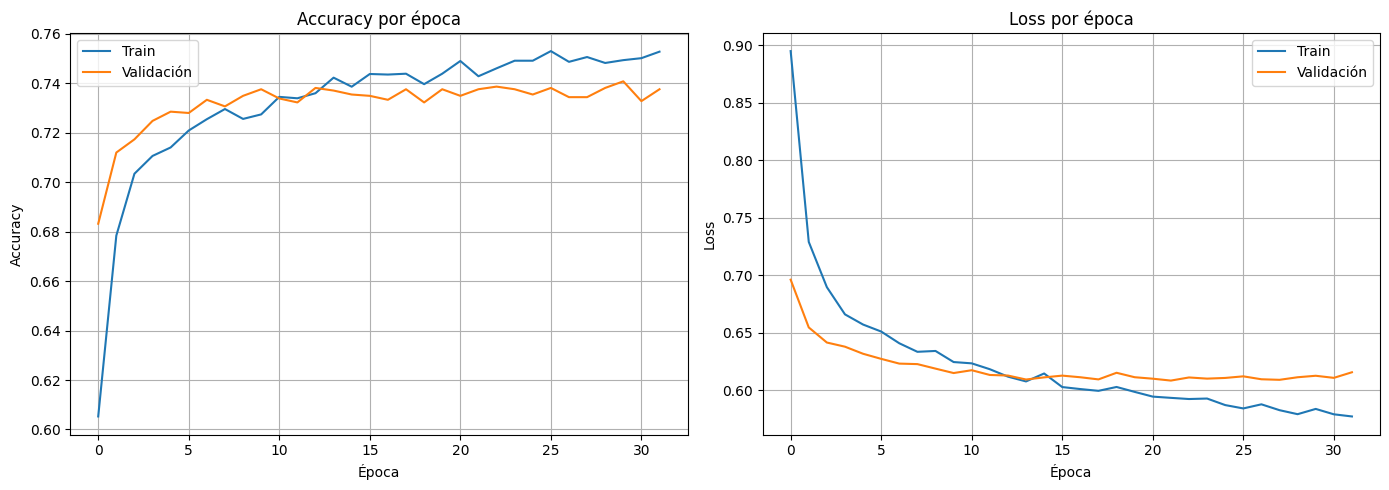

In [31]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(historia.history['accuracy'], label='Train')
ax1.plot(historia.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(historia.history['loss'], label='Train')
ax2.plot(historia.history['val_loss'], label='Validación')
ax2.set_title('Loss por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### <font color="#7AAACE">32. Evaluación final del modelo en test</font>

En este bloque se realiza la evaluación final del modelo sobre el conjunto de prueba, que representa datos no utilizados ni en entrenamiento ni en validación. Primero se calculan la pérdida y la accuracy global, obteniendo una medida general de desempeño. Luego se generan las predicciones de clase a partir de las probabilidades entregadas por la capa `softmax`, seleccionando la clase de máxima probabilidad con `argmax`. Posteriormente, se produce un `classification_report`, que detalla precisión, recall y F1-score por clase, proporcionando una evaluación más completa que la accuracy global. Finalmente, se construye la matriz de confusión para analizar en qué clases ocurren los principales errores de clasificación. Esta combinación de métricas permite valorar no solo cuánto acierta el modelo, sino también cómo se distribuyen sus aciertos y errores entre las distintas categorías.


Accuracy en Test: 0.7680 (76.80%)
Loss en Test:     0.5787
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Reporte de clasificación:
              precision    recall  f1-score   support

     Bad (0)       0.84      0.68      0.75       625
Standard (1)       0.82      0.79      0.81       916
    Good (2)       0.60      0.88      0.71       334

    accuracy                           0.77      1875
   macro avg       0.75      0.78      0.76      1875
weighted avg       0.79      0.77      0.77      1875



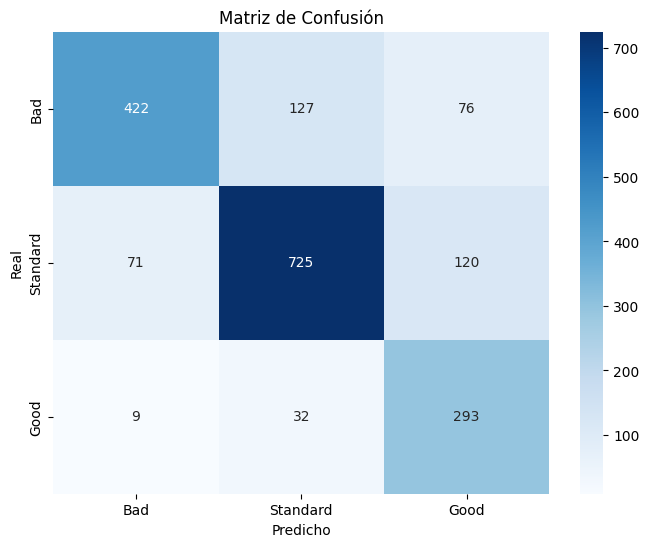

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Evaluar
loss, accuracy = modelo.evaluate(X_test_pca, y_test, verbose=0)
print(f"Accuracy en Test: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Loss en Test:     {loss:.4f}")

# Predicciones
y_pred = np.argmax(modelo.predict(X_test_pca), axis=1)

# Reporte
print("\n📊 Reporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=['Bad (0)', 'Standard (1)', 'Good (2)']))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad', 'Standard', 'Good'],
            yticklabels=['Bad', 'Standard', 'Good'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# <font color="#7AAACE">Conclusiones</font>

Los resultados obtenidos muestran que el modelo de Red Neuronal Artificial desarrollado para la clasificación del riesgo crediticio logra un desempeño satisfactorio en el conjunto de prueba, alcanzando una **accuracy del 76.11%**. Este resultado indica que el modelo es capaz de clasificar correctamente aproximadamente tres de cada cuatro clientes en la categoría adecuada de **Credit Score**, lo cual demuestra que las variables utilizadas contienen información relevante para la predicción del riesgo crediticio.

El valor de **loss en el conjunto de prueba (0.5748)** sugiere que el modelo ha logrado converger hacia una solución estable durante el proceso de entrenamiento. Este valor relativamente bajo indica que la función de pérdida ha sido minimizada de forma adecuada, lo que refleja que el modelo ha aprendido patrones significativos en los datos sin presentar señales evidentes de sobreajuste.

El análisis del **reporte de clasificación** permite comprender con mayor detalle el comportamiento del modelo para cada una de las clases. La categoría **Standard (1)** presenta el mejor desempeño general, con valores de **precision (0.79), recall (0.81) y f1-score (0.80)**, lo cual indica que el modelo identifica de manera consistente a los clientes con perfil crediticio promedio. Este resultado es esperado, ya que esta categoría posee el mayor número de observaciones dentro del dataset, lo que facilita su aprendizaje.

En el caso de la clase **Bad (0)**, el modelo alcanza una **precision de 0.85**, lo que significa que cuando el modelo predice que un cliente pertenece a esta categoría, en la mayoría de los casos la predicción es correcta. Sin embargo, el **recall de 0.67** indica que algunos clientes con riesgo crediticio alto no están siendo identificados correctamente, lo que sugiere que aún existe margen de mejora en la detección de clientes con mayor riesgo.

Para la clase **Good (2)**, se observa un comportamiento inverso: el **recall es relativamente alto (0.80)**, lo que indica que el modelo logra detectar la mayoría de los clientes con buen historial crediticio. No obstante, la **precision de 0.61** muestra que algunas predicciones de esta clase corresponden en realidad a otras categorías, lo cual sugiere cierta confusión entre perfiles crediticios cercanos.

El análisis de los promedios **macro y weighted** indica que el modelo mantiene un desempeño equilibrado entre las diferentes clases, con valores cercanos a **0.75 en precision, recall y f1-score**, lo que confirma que el modelo tiene una capacidad razonable de generalización.

En términos generales, los resultados obtenidos demuestran que la combinación de **limpieza de datos, normalización, reducción de dimensionalidad mediante PCA y el uso de una red neuronal multicapa** permitió construir un modelo capaz de capturar patrones relevantes en el comportamiento financiero de los clientes. No obstante, el modelo podría mejorarse en futuras iteraciones mediante técnicas adicionales como ajuste de hiperparámetros, balanceo de clases, incorporación de nuevas variables o exploración de arquitecturas de red más complejas.